# Simulations of neutrino system $N=4$.
We generate the first order Trotterized evolution for $N=4$.

In [1]:
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt
from iminuit import Minuit
from iminuit.cost import LeastSquares  
from core_functions_Trotter import *

In [2]:
I = qt.qeye(2)

def pauli_tensors(pauli, N):
        return [qt.tensor(*(pauli if k==i else I for k in range(N))) for i in range(N)]

def generate_heisenberg_hamiltonians(N, couplings, b, theta_mix):
    sx = pauli_tensors(qt.sigmax(), N)
    sy = pauli_tensors(qt.sigmay(), N)
    sz = pauli_tensors(qt.sigmaz(), N)

    H_0 = 0
    H_int = 0
    H_XY = 0
    H_XZ = 0
    H_YZ = 0

    for i in range(N):
        H_0 += b*(np.sin(2*theta_mix)*sx[i] - np.cos(2*theta_mix)*sz[i])
        for j in range(i+1, N):
            g = couplings[f"g{i+1}_{j+1}"]

            H_int += g*(sx[i]*sx[j] + sy[i]*sy[j] + sz[i]*sz[j])
            H_XY  += 0.5*g*(sx[i]*sx[j] + sy[i]*sy[j])
            H_XZ  += 0.5*g*(sx[i]*sx[j] + sz[i]*sz[j])
            H_YZ  += 0.5*g*(sy[i]*sy[j] + sz[i]*sz[j])

    return H_0, H_int, H_XY, H_XZ, H_YZ

In [3]:
N = 4   
mu = 1
theta_mixing = 0.195
upsilon = 0.9
b = mu / N # free Hamiltonian 

couplings, _ = fp_couplings(N, upsilon, mu)

def pauli_tensors(pauli, N):
    return [qt.tensor(*(pauli if i==j else I for j in range(N))) for i in range(N)]

sx, sy, sz = pauli_tensors(qt.sigmax(), N), pauli_tensors(qt.sigmay(), N), pauli_tensors(qt.sigmaz(), N)

H_0, H_int, H_XY, H_XZ, H_YZ = generate_heisenberg_hamiltonians(N, couplings, b, theta_mixing)

psi0011 = qt.tensor(qt.basis(2,0), qt.basis(2,0), qt.basis(2,1), qt.basis(2,1)) # |0011>

In [4]:
H = H_0 + H_int
X = qt.tensor(qt.sigmax(), qt.sigmax(), qt.sigmax(), qt.sigmax())

HX_psi0 = (H * X) * psi0011
XH_psi0 = (X * H) * psi0011

HX_psi0-XH_psi0

H2 = H * H
H2X_psi0 = (H2 * X) * psi0011
XH2_psi0 = (X * H2) * psi0011

H2X_psi0-XH2_psi0

Quantum object: dims=[[2, 2, 2, 2], [1, 1, 1, 1]], shape=(16, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.00000000e+00]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [-8.79099274e-02]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [-8.79099274e-02]
 [-3.46944695e-18]
 [ 3.46944695e-18]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 [ 8.79099274e-02]
 [ 8.79099274e-02]
 [ 0.00000000e+00]]

## Trotter error sanity check

In [5]:
dt_list = np.arange(1, 41) / mu

def compute_single_step_error_Heisenberg_T1(times):
    U_heis = [(-1j*H_int*t).expm()*(-1j*H_0*t).expm() for t in times]
    U_T1 = [(-1j*(H_YZ)*t).expm()*(-1j*(H_XZ)*t).expm()*(-1j*(H_XY)*t).expm()*(-1j*H_0*t).expm() for t in times]
    add_err_values = [np.max(np.linalg.svd((U_heis[i] - U_T1[i]).full(), compute_uv=False)) for i in range(len(times))]
    return U_heis, U_T1, add_err_values

_, _, add_T1_vals = compute_single_step_error_Heisenberg_T1(dt_list)

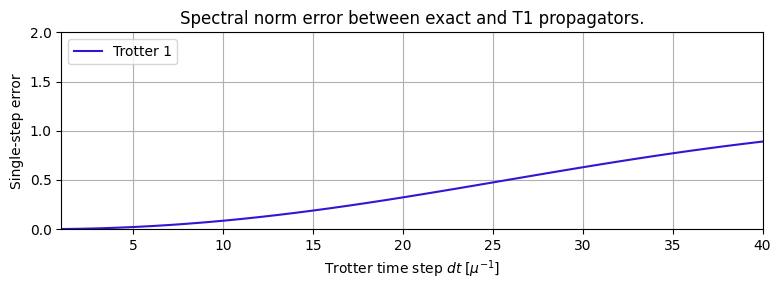

In [6]:
fig, ax=plt.subplots(figsize=(8,3))

ax.plot(dt_list, add_T1_vals, color="#3713d4", label="Trotter 1")
ax.set_title(r"Spectral norm error between exact and T1 propagators.")
ax.set_xlabel(r"Trotter time step $dt\;\left[\mu^{-1}\right]$")
ax.set_ylabel(r"Single-step error")
ax.text(0.02, 0.84, rf"", transform=ax.transAxes, fontsize=10, va="center", bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"))
ax.legend(loc=2)
ax.set_xlim(np.min(dt_list), np.max(dt_list))
ax.set_ylim(0, 2)

plt.grid()
plt.tight_layout()
plt.show()

## Z expectation value and inversion probabilities for the finite time evolution

In [11]:
dt = 1 / mu
N_iter = 201
tlist = [dt*k for k in range(N_iter)]

U_free = (-1j*H_0*dt).expm()
U_exact_dt = (-1j*H_int*dt).expm() * U_free
U_Trot1_dt = (-1j*(H_YZ)*dt).expm()*(-1j*(H_XZ)*dt).expm()*(-1j*(H_XY)*dt).expm() * U_free

psi_exact = []
psi_Trot1 = []

psi_exact.append(psi0011)
psi_Trot1.append(psi0011)

for i in range(1, N_iter):
    psi_exact.append(U_exact_dt*psi_exact[i-1])
    psi_Trot1.append(U_Trot1_dt*psi_Trot1[i-1])

exact_Z1_expvl = [qt.expect(sz[0], state) for state in psi_exact]
Trot1_Z1_expvl = [qt.expect(sz[0], state) for state in psi_Trot1]
exact_Z2_expvl = [qt.expect(sz[1], state) for state in psi_exact]
Trot1_Z2_expvl = [qt.expect(sz[1], state) for state in psi_Trot1]
exact_Z3_expvl = [qt.expect(sz[2], state) for state in psi_exact]
Trot1_Z3_expvl = [qt.expect(sz[2], state) for state in psi_Trot1]
exact_Z4_expvl = [qt.expect(sz[3], state) for state in psi_exact]
Trot1_Z4_expvl = [qt.expect(sz[3], state) for state in psi_Trot1]

invprob_1_exact = [abs(exact_Z1_expvl[0]-exact_Z1_expvl[i])/2 for i in range(0, len(exact_Z1_expvl))]
invprob_1_Trot1 = [abs(Trot1_Z1_expvl[0]-Trot1_Z1_expvl[i])/2 for i in range(0, len(Trot1_Z1_expvl))]
invprob_2_exact = [abs(exact_Z2_expvl[0]-exact_Z2_expvl[i])/2 for i in range(0, len(exact_Z2_expvl))]
invprob_2_Trot1 = [abs(Trot1_Z2_expvl[0]-Trot1_Z2_expvl[i])/2 for i in range(0, len(Trot1_Z2_expvl))]
invprob_3_exact = [abs(exact_Z3_expvl[0]-exact_Z3_expvl[i])/2 for i in range(0, len(exact_Z3_expvl))]
invprob_3_Trot1 = [abs(Trot1_Z3_expvl[0]-Trot1_Z3_expvl[i])/2 for i in range(0, len(Trot1_Z3_expvl))]
invprob_4_exact = [abs(exact_Z4_expvl[0]-exact_Z4_expvl[i])/2 for i in range(0, len(exact_Z4_expvl))]
invprob_4_Trot1 = [abs(Trot1_Z4_expvl[0]-Trot1_Z4_expvl[i])/2 for i in range(0, len(Trot1_Z4_expvl))]

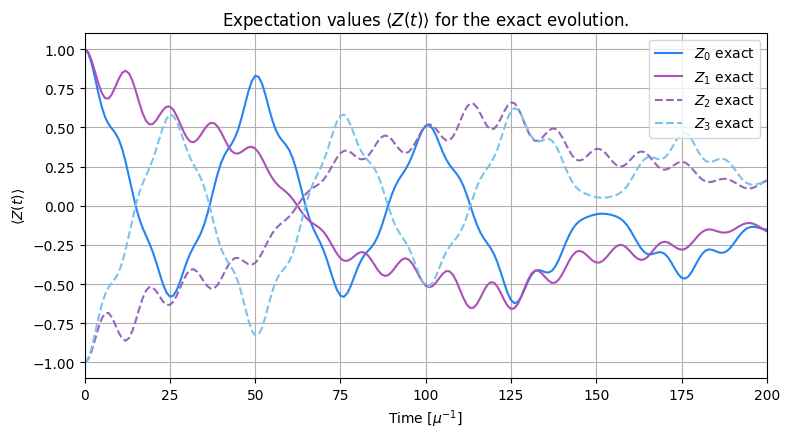

In [12]:
# ----------------
# --- Plotting --- 
# ----------------

show_Trotter = False


# ----- Plot Z expectation value -----

fig, ax=plt.subplots(figsize=(16/2,9/2))

ax.plot(tlist, exact_Z1_expvl, color="#2484f1", label=r"$Z_0$ exact")
ax.plot(tlist, exact_Z2_expvl, color="#ac50b8", label=r"$Z_1$ exact")
ax.plot(tlist, exact_Z3_expvl, color="#9467bd", linestyle="--", label=r"$Z_2$ exact")
ax.plot(tlist, exact_Z4_expvl, color="#7bc3ec", linestyle="--", label=r"$Z_3$ exact")

if show_Trotter:
    ax.plot(tlist, Trot1_Z1_expvl, color="#aec7e8", linestyle="--", label=r"$Z_0$ Trot1")
    ax.plot(tlist, Trot1_Z2_expvl, color="#98df8a", linestyle="--", label=r"$Z_1$ Trot1")
    ax.plot(tlist, Trot1_Z3_expvl, color="#c5b0d5", linestyle="--", label=r"$Z_2$ Trot1")
    ax.plot(tlist, Trot1_Z4_expvl, color="#ffbb78", linestyle="--", label=r"$Z_3$ Trot1")

ax.set_title(r"Expectation values $\langle Z(t)\rangle$ for the exact evolution.")
ax.set_xlabel(r"Time $[\mu^{-1}]$")
ax.set_ylabel(r"$\langle Z(t)\rangle$")
ax.text(0.02, 0.84, rf"", transform=ax.transAxes, fontsize=10, va="center", bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"))
ax.legend()
ax.set_xlim(np.min(tlist), np.max(tlist))
ax.set_ylim(-1.1, 1.1)

plt.grid()
plt.tight_layout()
plt.show()

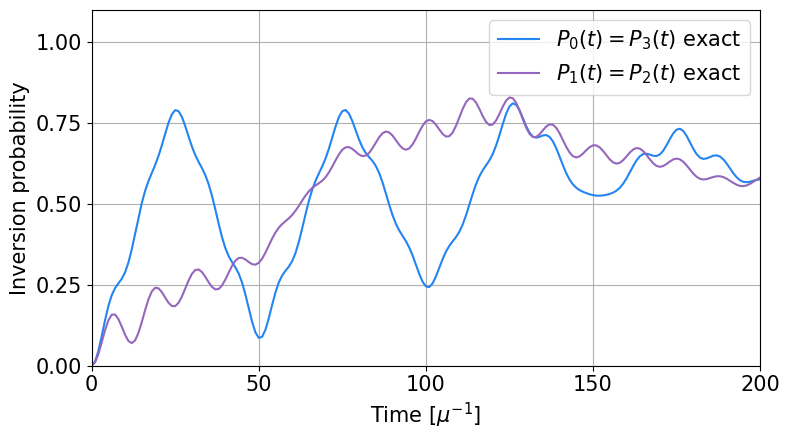

In [20]:
# ----- Plot inversion probabilities -----

fig, ax=plt.subplots(figsize=(16/2,9/2))

ax.plot(tlist, invprob_1_exact, color="#2484f1", label=r"$P_0(t)=P_3(t)$ exact")
ax.plot(tlist, invprob_2_exact, color="#9467bd", label=r"$P_1(t)=P_2(t)$ exact")
# ax.plot(tlist, invprob_3_exact, color="#9467bd")
# ax.plot(tlist, invprob_4_exact, color="#ff7f0e")

if show_Trotter:
    ax.plot(tlist, invprob_1_Trot1, color="#aec7e8", linestyle="--", label=r"$P_1(t)$ Trot1")
    ax.plot(tlist, invprob_2_Trot1, color="#98df8a", linestyle="--", label=r"$P_2(t)$ Trot1")
    ax.plot(tlist, invprob_3_Trot1, color="#c5b0d5", linestyle="--", label=r"$P_3(t)$ Trot1")
    ax.plot(tlist, invprob_4_Trot1, color="#ffbb78", linestyle="--", label=r"$P_4(t)$ Trot1")

#ax.set_title(r"Inversion probabilities $P(t)=|\langle Z(0)\rangle-\langle Z(t)\rangle|/2$ for the exact evolution.")
ax.set_xlabel(r"Time $[\mu^{-1}]$", fontsize=15)
ax.set_ylabel(r"Inversion probability", fontsize=15)
ax.legend(fontsize=15)
ax.set_xlim(np.min(tlist), np.max(tlist))
ax.set_ylim(0, 1.1)
ax.set_xticks([0,50,100,150,200])
ax.set_yticks([0,0.25,0.5,0.75,1])
ax.tick_params("both", labelsize=15)

plt.grid()
plt.tight_layout()
plt.show()

In [13]:
T_total = 100
dt = 1 / mu
dt_fine = 0.01 / mu

tlist = [dt*i for i in range(int(T_total/dt))]
tlist_fine = [dt_fine*i for i in range(int(T_total/dt_fine))]

res = qt.mesolve(H_0+H_int, psi0011, tlist_fine, [], [sz[0], sz[1], sz[2], sz[3]])

exact_Z1_expvl, exact_Z2_expvl, exact_Z3_expvl, exact_Z4_expvl = res.expect

exact_Z1_expvl = np.array(exact_Z1_expvl)
exact_Z2_expvl = np.array(exact_Z2_expvl)
exact_Z3_expvl = np.array(exact_Z3_expvl)
exact_Z4_expvl = np.array(exact_Z4_expvl)

psi_Trot1 = [psi0011]

for i in range(1, int(T_total/dt)): psi_Trot1.append(U_Trot1_dt*psi_Trot1[i-1])

Trot1_Z1_expvl = [qt.expect(sz[0], state) for state in psi_Trot1]
Trot1_Z2_expvl = [qt.expect(sz[1], state) for state in psi_Trot1]
Trot1_Z3_expvl = [qt.expect(sz[2], state) for state in psi_Trot1]
Trot1_Z4_expvl = [qt.expect(sz[3], state) for state in psi_Trot1]

invprob_1_exact = [abs(exact_Z1_expvl[0]-exact_Z1_expvl[i])/2 for i in range(0, len(exact_Z1_expvl))]
invprob_1_Trot1 = [abs(Trot1_Z1_expvl[0]-Trot1_Z1_expvl[i])/2 for i in range(0, len(Trot1_Z1_expvl))]
invprob_2_exact = [abs(exact_Z2_expvl[0]-exact_Z2_expvl[i])/2 for i in range(0, len(exact_Z2_expvl))]
invprob_2_Trot1 = [abs(Trot1_Z2_expvl[0]-Trot1_Z2_expvl[i])/2 for i in range(0, len(Trot1_Z2_expvl))]
invprob_3_exact = [abs(exact_Z3_expvl[0]-exact_Z3_expvl[i])/2 for i in range(0, len(exact_Z3_expvl))]
invprob_3_Trot1 = [abs(Trot1_Z3_expvl[0]-Trot1_Z3_expvl[i])/2 for i in range(0, len(Trot1_Z3_expvl))]
invprob_4_exact = [abs(exact_Z4_expvl[0]-exact_Z4_expvl[i])/2 for i in range(0, len(exact_Z4_expvl))]
invprob_4_Trot1 = [abs(Trot1_Z4_expvl[0]-Trot1_Z4_expvl[i])/2 for i in range(0, len(Trot1_Z4_expvl))]

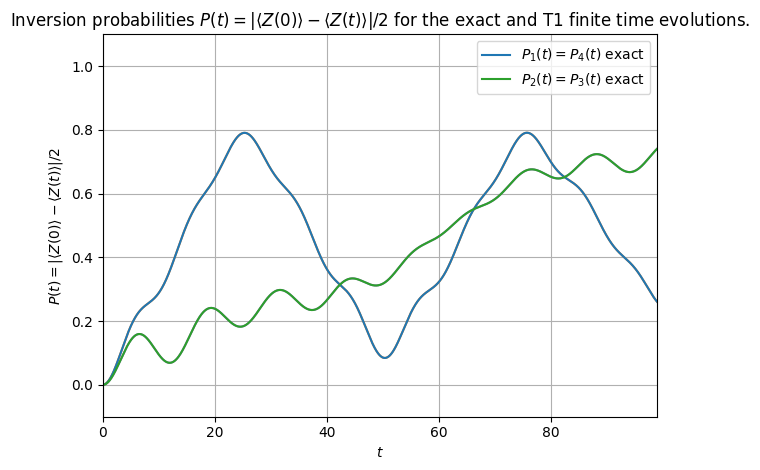

In [15]:
# ----- Plot inversion probabilities -----

fig, ax=plt.subplots()

ax.plot(tlist_fine, invprob_3_exact, color="#9467bd")
ax.plot(tlist_fine, invprob_4_exact, color="#ff7f0e")
ax.plot(tlist_fine, invprob_1_exact, color="#1f77b4", label=r"$P_1(t)=P_4(t)$ exact")
ax.plot(tlist_fine, invprob_2_exact, color="#2ca02c", label=r"$P_2(t)=P_3(t)$ exact")

# ax.plot(tlist, invprob_3_Trot1, color="#c5b0d5", linestyle="--")
# ax.plot(tlist, invprob_4_Trot1, color="#ffbb78", linestyle="--")
# ax.plot(tlist, invprob_1_Trot1, color="#aec7e8", linestyle="--", label=r"$P_1(t)=P_4(t)$ Trotter 1")
# ax.plot(tlist, invprob_2_Trot1, color="#98df8a", linestyle="--", label=r"$P_2(t)=P_3(t)$ Trotter 1")

ax.set_title(r"Inversion probabilities $P(t)=|\langle Z(0)\rangle-\langle Z(t)\rangle|/2$ for the exact and T1 finite time evolutions.")
ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$P(t)=|\langle Z(0)\rangle-\langle Z(t)\rangle|/2$")
ax.text(0.02, 0.84, rf"", transform=ax.transAxes, fontsize=10, va="center", bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"))
ax.legend()
ax.set_xlim(np.min(tlist), np.max(tlist))
ax.set_ylim(-0.1, 1.1)

plt.grid()
plt.tight_layout()
plt.show()

## Inversion probabilities as a function of the Trotter time step $dt$ (fig. 5 Trapped Ions paper)

In [98]:
N = 4
mu = 1
theta_mixing = 0.195
upsilon = 0.9
b = mu / N # free Hamiltonian 

couplings, _ = fp_couplings(N, upsilon, mu)

def pauli_tensors(pauli, N):
    return [qt.tensor(*(pauli if i==j else I for j in range(N))) for i in range(N)]

sx, sy, sz = pauli_tensors(qt.sigmax(), N), pauli_tensors(qt.sigmay(), N), pauli_tensors(qt.sigmaz(), N)

dt_list = np.arange(1, 40) / mu

psi0011 = qt.tensor(qt.basis(2,0), qt.basis(2,0), qt.basis(2,1), qt.basis(2,1)) # |0011>
expect_Z0_0 = qt.expect(sz[0], psi0011)
expect_Z1_0 = qt.expect(sz[1], psi0011)
expect_Z2_0 = qt.expect(sz[2], psi0011)
expect_Z3_0 = qt.expect(sz[3], psi0011)

invprob_dt_exact_0 = []
invprob_dt_Trot1_0 = []
invprob_dt_exact_1 = []
invprob_dt_Trot1_1 = []
invprob_dt_exact_2 = []
invprob_dt_Trot1_2 = []
invprob_dt_exact_3 = []
invprob_dt_Trot1_3 = []


for dt in dt_list:
    U_free = (-1j*H_0*dt).expm()
    U_exact_dt = (-1j*H_int*dt).expm() * U_free
    U_Trot1_dt = (-1j*(H_YZ)*dt).expm()*(-1j*(H_XZ)*dt).expm()*(-1j*(H_XY)*dt).expm() * U_free

    invprob_dt_exact_0.append(abs(expect_Z0_0-qt.expect(sz[0], U_exact_dt*psi0011))/2)
    invprob_dt_Trot1_0.append(abs(expect_Z0_0-qt.expect(sz[0], U_Trot1_dt*psi0011))/2)
    invprob_dt_exact_1.append(abs(expect_Z1_0-qt.expect(sz[1], U_exact_dt*psi0011))/2)
    invprob_dt_Trot1_1.append(abs(expect_Z1_0-qt.expect(sz[1], U_Trot1_dt*psi0011))/2)
    invprob_dt_exact_2.append(abs(expect_Z2_0-qt.expect(sz[2], U_exact_dt*psi0011))/2)
    invprob_dt_Trot1_2.append(abs(expect_Z2_0-qt.expect(sz[2], U_Trot1_dt*psi0011))/2)
    invprob_dt_exact_3.append(abs(expect_Z3_0-qt.expect(sz[3], U_exact_dt*psi0011))/2)
    invprob_dt_Trot1_3.append(abs(expect_Z3_0-qt.expect(sz[3], U_Trot1_dt*psi0011))/2)


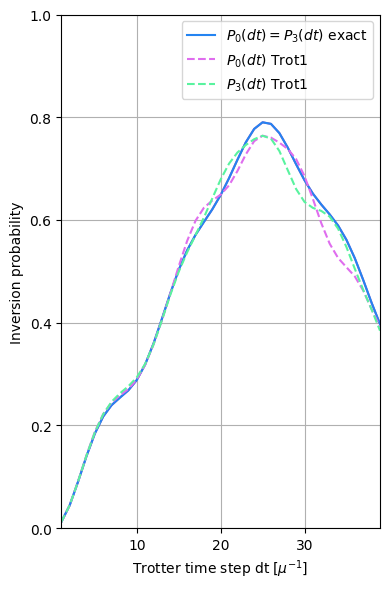

In [ ]:

# ----------------
# --- Plotting --- 
# ----------------

show_Trotter = True

# ----- Plot inversion probabilities nu0, nu3 -----

fig, ax=plt.subplots(figsize=(4,6))

ax.plot(dt_list, invprob_dt_exact_3, color="#ac50b8")
ax.plot(dt_list, invprob_dt_exact_0, color="#2484f1", label=r"$P_0(dt)=P_3(dt)$ exact")

if show_Trotter:
    ax.plot(dt_list, invprob_dt_Trot1_0, color="#df6dee", linestyle="--", label=r"$P_0(dt)$ Trot1")
    ax.plot(dt_list, invprob_dt_Trot1_3, color="#59f39f", linestyle="--", label=r"$P_3(dt)$ Trot1")

# ax.set_title(r"Inversion probabilities after a single Trotter time step for neutrinos $\nu_0$, $\nu_3$.")
ax.set_xlabel(r"Trotter time step $\text{dt}\; \left[\mu^{-1}\right]$")
ax.set_ylabel(r"Inversion probability")
ax.text(0.02, 0.84, rf"", transform=ax.transAxes, fontsize=10, va="center", bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"))
ax.legend()
ax.set_xlim(np.min(dt_list), np.max(dt_list))
ax.set_ylim(0, 1)

plt.grid()
plt.tight_layout()
plt.show()


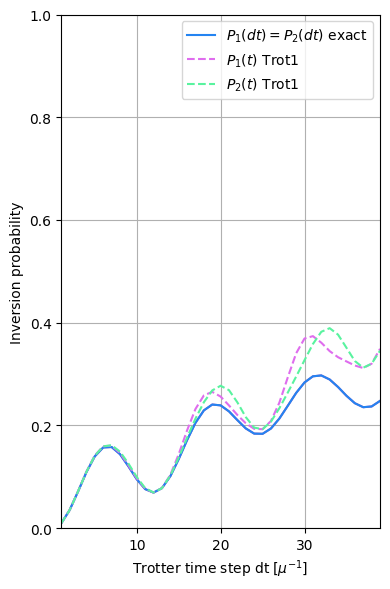

In [100]:

# ----- Plot inversion probabilities nu1, nu2 -----

fig, ax=plt.subplots(figsize=(4,6))

ax.plot(dt_list, invprob_dt_exact_1, color="#ac50b8")
ax.plot(dt_list, invprob_dt_exact_2, color="#2484f1", label=r"$P_1(dt)=P_2(dt)$ exact")

if show_Trotter:
    ax.plot(dt_list, invprob_dt_Trot1_1, color="#df6dee", linestyle="--", label=r"$P_1(t)$ Trot1")
    ax.plot(dt_list, invprob_dt_Trot1_2, color="#59f39f", linestyle="--", label=r"$P_2(t)$ Trot1")

# ax.set_title(r"Inversion probabilities after a single Trotter time step for neutrinos $\nu_1$, $\nu_2$.")
ax.set_xlabel(r"Trotter time step $\text{dt}\; \left[\mu^{-1}\right]$")
ax.set_ylabel(r"Inversion probability")
ax.text(0.02, 0.84, rf"", transform=ax.transAxes, fontsize=10, va="center", bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"))
ax.legend()
ax.set_xlim(np.min(dt_list), np.max(dt_list))
ax.set_ylim(0, 1)

plt.grid()
plt.tight_layout()
plt.show()

## Time evolution of the inversion probability for neutrino $\nu_1$ using a time step $dt = 16\mu^{-1}$ (fig. 6)

In [5]:
N = 4
mu = 1
theta_mixing = 0.195
upsilon = 0.9
b = mu / N # free Hamiltonian 

couplings, _ = fp_couplings(N, upsilon, mu)

def pauli_tensors(pauli, N):
    return [qt.tensor(*(pauli if i==j else I for j in range(N))) for i in range(N)]

sx, sy, sz = pauli_tensors(qt.sigmax(), N), pauli_tensors(qt.sigmay(), N), pauli_tensors(qt.sigmaz(), N)

T_total = 1200

# dt_fine = 1 / mu
# tlist_fine = [dt_fine*i for i in range(int(T_total/dt_fine))]

# res = qt.mesolve(H_0+H_int, psi0011, tlist_fine, [], [sz[0], sz[1], sz[2], sz[3]])
# 
# _, exact_Z1_expvl, _, _ = res.expect
# exact_Z1_expvl = np.array(exact_Z1_expvl)
# invprob_1_exact_fine = [abs(exact_Z1_expvl[0]-exact_Z1_expvl[i])/2 for i in range(0, len(exact_Z1_expvl))]

dt_exact = 1 / mu
dt = 16 / mu

r_exact = int(T_total / dt_exact)
r_Trot1 = int(T_total / dt)

U_free_dt_exact = (-1j*H_0*dt_exact).expm()
U_exact_dt_exact = (-1j*H_int*dt_exact).expm() * U_free_dt_exact

U_free_dt = (-1j*H_0*dt).expm()
U_Trot1_dt = (-1j*(H_YZ)*dt).expm()*(-1j*(H_XZ)*dt).expm()*(-1j*(H_XY)*dt).expm() * U_free_dt

psi0011 = qt.tensor(qt.basis(2,0), qt.basis(2,0), qt.basis(2,1), qt.basis(2,1)) # |0011>

psi_exact = []
psi_Trot1 = []

psi_exact.append(psi0011)
psi_Trot1.append(psi0011)

for i in range(1, r_exact): psi_exact.append(U_exact_dt_exact*psi_exact[i-1])
for i in range(1, r_Trot1): psi_Trot1.append(U_Trot1_dt*psi_Trot1[i-1])

tlist_exact = [dt_exact*k for k in range(0, r_exact)]
tlist_Trot1 = [dt*k for k in range(0, r_Trot1)]

exact_Z1_expvl = [qt.expect(sz[1], state) for state in psi_exact]
Trot1_Z1_expvl = [qt.expect(sz[1], state) for state in psi_Trot1]

invprob_1_exact = [abs(exact_Z1_expvl[0]-exact_Z1_expvl[i])/2 for i in range(0, len(exact_Z1_expvl))]
invprob_1_Trot1 = [abs(Trot1_Z1_expvl[0]-Trot1_Z1_expvl[i])/2 for i in range(0, len(Trot1_Z1_expvl))]

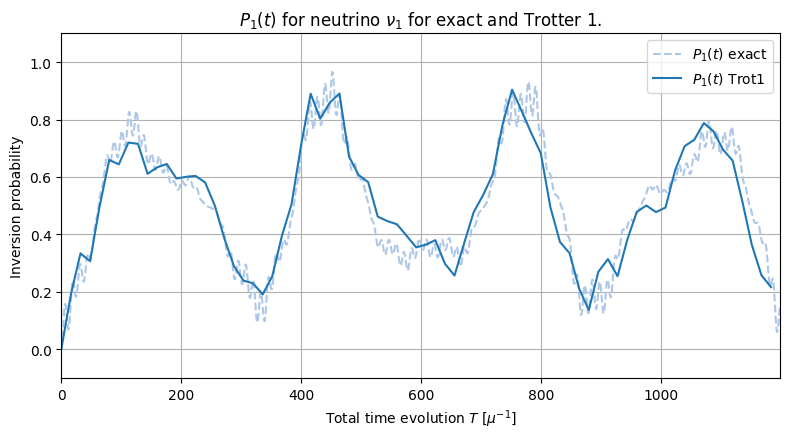

In [6]:
# ----- Plot inversion probabilities -----

fig, ax=plt.subplots(figsize=(16/2,9/2))

ax.plot(tlist_exact, invprob_1_exact, color="#aec7e8", linestyle="--", label=r"$P_1(t)$ exact")
ax.plot(tlist_Trot1, invprob_1_Trot1, color="#1f77b4", label=r"$P_1(t)$ Trot1")
# ax.plot(tlist_exact_fine, invprob_1_exact_fine, color="#103957", label=r"$P_1(t)$ fine")

ax.set_title(r"$P_1(t)$ for neutrino $\nu_1$ for exact and Trotter 1.")
ax.set_xlabel(r"Total time evolution $T\;[\mu^{-1}]$")
ax.set_ylabel(r"Inversion probability")
ax.text(0.02, 0.84, rf"", transform=ax.transAxes, fontsize=10, va="center", bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"))
ax.legend()
ax.set_xlim(np.min(tlist_exact), np.max(tlist_exact))
ax.set_ylim(-0.1, 1.1)

plt.grid()
plt.tight_layout()
plt.show()